In [5]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Please enable GPU runtime.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4


In [6]:
!pip install -q transformers datasets evaluate accelerate scikit-learn tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00


In [9]:
import torch
import transformers
import datasets
import evaluate
import sklearn
import matplotlib

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)

torch: 2.10.0+cu128
transformers: 5.0.0
datasets: 4.0.0
evaluate: 0.4.6


In [10]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [11]:
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

MODEL_NAME = "bert-base-uncased"
TASK_NAME = "sst2"
MAX_LENGTH = 128
BATCH_SIZE = 32

In [12]:
raw_datasets = load_dataset("glue", TASK_NAME)

print(raw_datasets)
print(raw_datasets["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(tokenizer)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)


In [14]:
example = raw_datasets["train"][0]["sentence"]
encoded = tokenizer(example, truncation=True, padding="max_length", max_length=MAX_LENGTH)

print("sentence:", example)
print("input_ids:", encoded["input_ids"][:20])
print("attention_mask:", encoded["attention_mask"][:20])

sentence: hide new secretions from the parental units 
input_ids: [101, 5342, 2047, 3595, 8496, 2013, 1996, 18643, 3197, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [15]:
def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

print(tokenized_datasets)

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})


In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

train_dataset = tokenized_datasets["train"]
valid_dataset = tokenized_datasets["validation"]

print(train_dataset[0])

{'labels': tensor(0), 'input_ids': tensor([  101,  5342,  2047,  3595,  8496,  2013,  1996, 18643,  3197,   102,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0, 

Hugging Face 모델들이 label 이름으로 보통 labels 를 기대함

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

batch = next(iter(train_loader))

print(batch.keys())
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
torch.Size([32, 128])
torch.Size([32, 128])
torch.Size([32])


한 batch에 문장 32개가 있고, 각 문장이 최대 길이 128 token으로 변환됨

In [18]:
from transformers import AutoModelForSequenceClassification

num_labels = 2

baseline_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

baseline_model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [20]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS = 1
#일단 1로 하고 나중에 2 또는 3으로 늘리기
LEARNING_RATE = 2e-5

optimizer = AdamW(
    baseline_model.parameters(),
    lr=LEARNING_RATE
)

num_training_steps = EPOCHS * len(train_loader)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

print("num_training_steps:", num_training_steps)

num_training_steps: 2105


In [21]:
import torch
from tqdm.auto import tqdm

#validation set에서 loss와 accuracy를 계산합니다.
def evaluate_accuracy(model, dataloader):
    model.eval()

    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=-1)
            labels = batch["labels"]

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item() * labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc

In [24]:
#학습 전 baseline 성능 확인
valid_loss, valid_acc = evaluate_accuracy(baseline_model, valid_loader)

print(f"Before fine-tuning | valid_loss: {valid_loss:.4f} | valid_acc: {valid_acc:.4f}")

Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]

Before fine-tuning | valid_loss: 0.6953 | valid_acc: 0.4862


In [25]:
#BERT fine-tuning 실행
baseline_model.train()

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    total_train_loss = 0.0
    total_seen = 0

    progress_bar = tqdm(train_loader, desc="Training")

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = baseline_model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        batch_size = batch["labels"].size(0)
        total_train_loss += loss.item() * batch_size
        total_seen += batch_size

        progress_bar.set_postfix({"loss": total_train_loss / total_seen})

    valid_loss, valid_acc = evaluate_accuracy(baseline_model, valid_loader)
    print(f"Validation | loss: {valid_loss:.4f} | acc: {valid_acc:.4f}")

Epoch 1/1


Training:   0%|          | 0/2105 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]

Validation | loss: 0.2028 | acc: 0.9255


In [26]:
# 로컬 저장
SAVE_DIR = "./bert_sst2_baseline"
baseline_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Drive에도 백업
import shutil
shutil.copytree(SAVE_DIR,
                '/content/drive/MyDrive/deebert/bert_sst2_baseline',
                dirs_exist_ok=True)

print("로컬 + Drive 저장 완료!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

로컬 + Drive 저장 완료!


In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DeeBERTForSST2(nn.Module):
    def __init__(self, baseline_model):
        super().__init__()

        self.config = baseline_model.config
        self.num_layers = baseline_model.config.num_hidden_layers
        self.hidden_size = baseline_model.config.hidden_size
        self.num_labels = baseline_model.config.num_labels

        # Fine-tuned BERT backbone
        self.bert = baseline_model.bert

        # Intermediate off-ramps: layer 1 ~ layer 11
        self.off_ramps = nn.ModuleList([
            nn.Linear(self.hidden_size, self.num_labels)
            for _ in range(self.num_layers - 1)
        ])

        # Final off-ramp: original fine-tuned BERT classifier
        self.final_dropout = baseline_model.dropout
        self.final_classifier = baseline_model.classifier

        # Freeze BERT backbone and final classifier
        for param in self.bert.parameters():
            param.requires_grad = False

        for param in self.final_classifier.parameters():
            param.requires_grad = False

    def forward_all_logits(self, input_ids, attention_mask, token_type_ids=None):
        """
        Return logits from all off-ramps.
        logits_list[0]  = layer 1 off-ramp
        logits_list[10] = layer 11 off-ramp
        logits_list[11] = final BERT classifier
        """

        # BERT backbone is frozen, so we do not need gradients here.
        with torch.no_grad():
            outputs = self.bert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                output_hidden_states=True,
                return_dict=True,
            )

            hidden_states = outputs.hidden_states
            pooled_output = outputs.pooler_output

        logits_list = []

        # hidden_states[0] is embedding output.
        # hidden_states[1] ~ hidden_states[12] are outputs of transformer layers.
        for layer_idx, head in enumerate(self.off_ramps):
            cls_hidden = hidden_states[layer_idx + 1][:, 0, :]
            logits = head(cls_hidden)
            logits_list.append(logits)

        # Final layer uses original BERT sequence classification head.
        final_logits = self.final_classifier(self.final_dropout(pooled_output))
        logits_list.append(final_logits)

        return logits_list

In [40]:
deebert_model = DeeBERTForSST2(baseline_model)
deebert_model.to(device)

trainable_params = sum(p.numel() for p in deebert_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in deebert_model.parameters())

print("Total params:", total_params)
print("Trainable params:", trainable_params)
print("Number of off-ramps:", len(deebert_model.off_ramps) + 1)

Total params: 109500696
Trainable params: 16918
Number of off-ramps: 12


In [41]:
from torch.optim import AdamW
from tqdm.auto import tqdm

OFFRAMP_EPOCHS = 1
OFFRAMP_LR = 1e-3

criterion = nn.CrossEntropyLoss()

offramp_optimizer = AdamW(
    deebert_model.off_ramps.parameters(),
    lr=OFFRAMP_LR
)

In [42]:
for epoch in range(OFFRAMP_EPOCHS):
    print(f"Off-ramp training epoch {epoch + 1}/{OFFRAMP_EPOCHS}")

    deebert_model.train()

    # Important: frozen BERT should stay in eval mode.
    deebert_model.bert.eval()
    deebert_model.final_classifier.eval()

    total_loss = 0.0
    total_seen = 0

    progress_bar = tqdm(train_loader, desc="Training off-ramps")

    for batch in progress_bar:
        labels = batch["labels"].to(device)

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        logits_list = deebert_model.forward_all_logits(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        # Train only intermediate off-ramps: layer 1 ~ layer 11.
        losses = []
        for logits in logits_list[:-1]:
            losses.append(criterion(logits, labels))

        loss = sum(losses) / len(losses)

        offramp_optimizer.zero_grad()
        loss.backward()
        offramp_optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_seen += batch_size

        progress_bar.set_postfix({"loss": total_loss / total_seen})

    print(f"Average training loss: {total_loss / total_seen:.4f}")

Off-ramp training epoch 1/1


Training off-ramps:   0%|          | 0/2105 [00:00<?, ?it/s]

Average training loss: 0.3411


In [43]:
torch.save(deebert_model.state_dict(),
           '/content/drive/MyDrive/deebert/deebert_model.pth')
print("Drive 저장 완료!")

Drive 저장 완료!


In [44]:
def evaluate_layerwise_accuracy(model, dataloader):
    model.eval()

    correct_by_layer = [0 for _ in range(model.num_layers)]
    total = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Layerwise evaluation"):
            labels = batch["labels"].to(device)

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            logits_list = model.forward_all_logits(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )

            for layer_idx, logits in enumerate(logits_list):
                preds = torch.argmax(logits, dim=-1)
                correct_by_layer[layer_idx] += (preds == labels).sum().item()

            total += labels.size(0)

    acc_by_layer = [correct / total for correct in correct_by_layer]
    return acc_by_layer

layerwise_acc = evaluate_layerwise_accuracy(deebert_model, valid_loader)

for i, acc in enumerate(layerwise_acc, start=1):
    print(f"Layer {i:2d} accuracy: {acc:.4f}")

Layerwise evaluation:   0%|          | 0/28 [00:00<?, ?it/s]

Layer  1 accuracy: 0.6984
Layer  2 accuracy: 0.7328
Layer  3 accuracy: 0.7546
Layer  4 accuracy: 0.7752
Layer  5 accuracy: 0.7775
Layer  6 accuracy: 0.8211
Layer  7 accuracy: 0.8475
Layer  8 accuracy: 0.8532
Layer  9 accuracy: 0.8888
Layer 10 accuracy: 0.9278
Layer 11 accuracy: 0.9266
Layer 12 accuracy: 0.9255


In [45]:
def compute_entropy_from_logits(logits):
    """
    logits: [batch_size, num_labels]
    return: entropy [batch_size]
    """
    probs = torch.softmax(logits, dim=-1)
    log_probs = torch.log(probs + 1e-12)
    entropy = -(probs * log_probs).sum(dim=-1)
    return entropy

In [46]:
def evaluate_early_exit(model, dataloader, threshold):
    model.eval()

    n_layers = model.num_layers

    correct = 0
    total = 0

    exit_layer_counts = [0 for _ in range(n_layers)]

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Early exit eval S={threshold:.2f}"):
            labels = batch["labels"].to(device)

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            logits_list = model.forward_all_logits(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
            )

            batch_size = labels.size(0)

            # 각 sample이 아직 exit하지 않았는지 표시
            exited = torch.zeros(batch_size, dtype=torch.bool, device=device)
            final_preds = torch.zeros(batch_size, dtype=torch.long, device=device)
            final_exit_layers = torch.zeros(batch_size, dtype=torch.long, device=device)

            for layer_idx, logits in enumerate(logits_list):
                layer_number = layer_idx + 1

                entropy = compute_entropy_from_logits(logits)
                preds = torch.argmax(logits, dim=-1)

                # 마지막 layer에서는 무조건 exit
                if layer_number == n_layers:
                    should_exit = ~exited
                else:
                    should_exit = (~exited) & (entropy < threshold)

                final_preds[should_exit] = preds[should_exit]
                final_exit_layers[should_exit] = layer_number
                exited = exited | should_exit

            correct += (final_preds == labels).sum().item()
            total += batch_size

            for layer_number in range(1, n_layers + 1):
                exit_layer_counts[layer_number - 1] += (final_exit_layers == layer_number).sum().item()

    accuracy = correct / total

    avg_exit_layer = sum(
        (i + 1) * count for i, count in enumerate(exit_layer_counts)
    ) / total

    expected_saving = 1.0 - (avg_exit_layer / n_layers)
    approx_speedup = n_layers / avg_exit_layer

    return {
        "threshold": threshold,
        "accuracy": accuracy,
        "avg_exit_layer": avg_exit_layer,
        "expected_saving": expected_saving,
        "approx_speedup": approx_speedup,
        "exit_layer_counts": exit_layer_counts,
    }

In [47]:
thresholds = [
    0.00,
    0.01,
    0.03,
    0.05,
    0.08,
    0.10,
    0.15,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.69,
]

early_exit_results = []

for threshold in thresholds:
    result = evaluate_early_exit(deebert_model, valid_loader, threshold)
    early_exit_results.append(result)

Early exit eval S=0.00:   0%|          | 0/28 [00:00<?, ?it/s]

Early exit eval S=0.01:   0%|          | 0/28 [00:00<?, ?it/s]

Early exit eval S=0.03:   0%|          | 0/28 [00:00<?, ?it/s]

Early exit eval S=0.05:   0%|          | 0/28 [00:00<?, ?it/s]

Early exit eval S=0.08:   0%|          | 0/28 [00:00<?, ?it/s]

...

Early exit eval S=0.30:   0%|          | 0/28 [00:00<?, ?it/s]

Early exit eval S=0.40:   0%|          | 0/28 [00:00<?, ?it/s]

Early exit eval S=0.50:   0%|          | 0/28 [00:00<?, ?it/s]

Early exit eval S=0.60:   0%|          | 0/28 [00:00<?, ?it/s]

Early exit eval S=0.69:   0%|          | 0/28 [00:00<?, ?it/s]

In [52]:
import pandas as pd

baseline_acc = layerwise_acc[-1]

rows = []

for result in early_exit_results:
    rows.append({
        "S": result["threshold"],
        "accuracy": result["accuracy"],
        "acc_drop": baseline_acc - result["accuracy"],
        "avg_exit_layer": result["avg_exit_layer"],
        "expected_saving_%": result["expected_saving"] * 100,
        "approx_speedup": result["approx_speedup"],
    })

result_df = pd.DataFrame(rows)

result_df

,S,accuracy,acc_drop,avg_exit_layer,expected_saving_%,approx_speedup
0,0.00,0.925459,0.000000,12.000000,0.000000,1.000000
1,0.01,0.925459,0.000000,10.958716,8.677370,1.095019
2,0.03,0.927752,-0.002294,10.216743,14.860474,1.174543
3,0.05,0.928899,-0.003440,9.782110,18.482416,1.226729
4,0.08,0.930046,-0.004587,9.383028,21.808104,1.278905
5,0.10,0.930046,-0.004587,9.094037,24.216361,1.319546
6,0.15,0.928899,-0.003440,8.525229,28.956422,1.407587
7,0.20,0.930046,-0.004587,8.022936,33.142202,1.495712
8,0.30,0.922018,0.003440,7.103211,40.806575,1.689377
9,0.40,0.896789,0.028670,5.986239,50.114679,2.004598


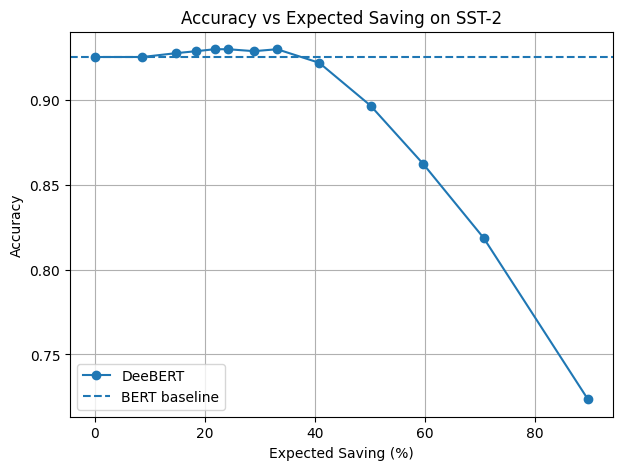

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    result_df["expected_saving_%"],
    result_df["accuracy"],
    marker="o",
    label="DeeBERT"
)

plt.axhline(
    y=baseline_acc,
    linestyle="--",
    label="BERT baseline"
)

plt.xlabel("Expected Saving (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Expected Saving on SST-2")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
def plot_exit_distribution(result, title=None):
    counts = result["exit_layer_counts"]
    total = sum(counts)
    fractions = [count / total for count in counts]

    layers = list(range(1, len(counts) + 1))

    plt.figure(figsize=(7, 4))
    plt.bar(layers, fractions)
    plt.xlabel("Exit Layer")
    plt.ylabel("Fraction of Samples")

    if title is None:
        title = f"Exit Distribution, S={result['threshold']:.2f}"
    plt.title(title)

    plt.xticks(layers)
    plt.grid(axis="y")
    plt.show()

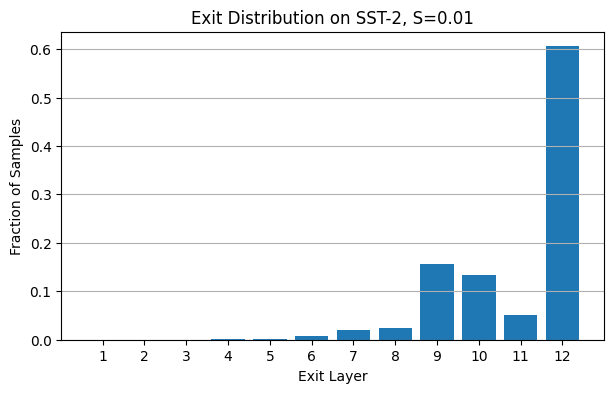

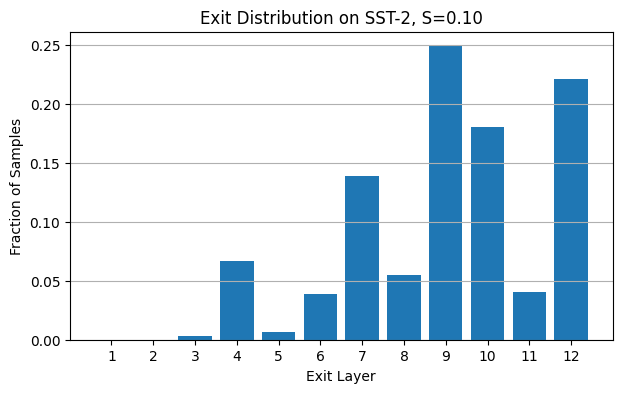

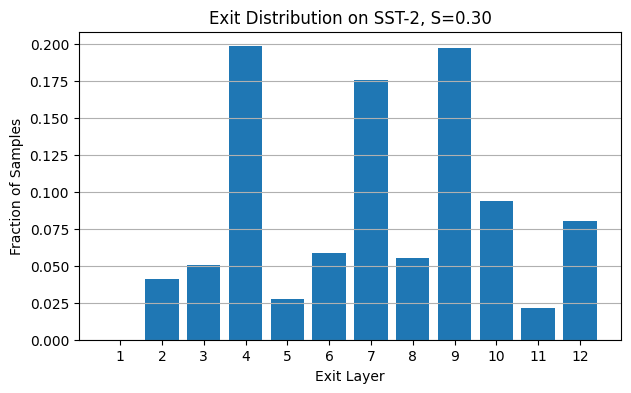

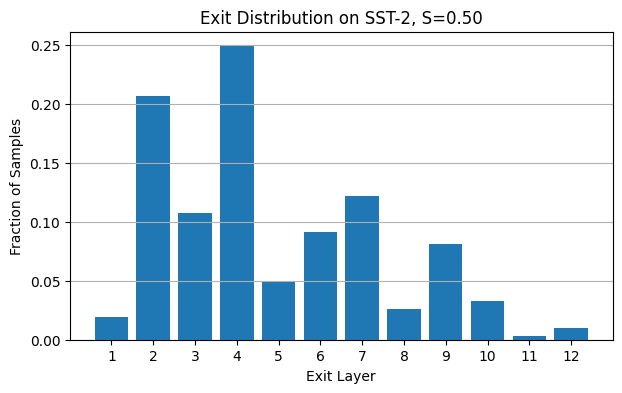

In [51]:
for target_s in [0.01, 0.10, 0.30, 0.50]:
    selected = min(
        early_exit_results,
        key=lambda r: abs(r["threshold"] - target_s)
    )

    plot_exit_distribution(
        selected,
        title=f"Exit Distribution on SST-2, S={selected['threshold']:.2f}"
    )

In [53]:
from torch.utils.data import DataLoader

latency_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
)

print("num validation samples:", len(valid_dataset))

num validation samples: 872


In [54]:
import time

def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

In [57]:
def actual_early_exit_forward(model, input_ids, attention_mask, token_type_ids=None, threshold=0.0):
    """
    실제 layer-by-layer early exit forward.
    batch_size=1 기준으로 사용합니다.

    return:
        logits: 최종 선택된 off-ramp의 logits
        exit_layer: 몇 번째 layer에서 exit했는지
    """
    model.eval()
    bert = model.bert

    batch_size = input_ids.size(0)
    assert batch_size == 1, "Actual early exit latency measurement uses batch_size=1."

    input_shape = input_ids.size()

    if attention_mask is None:
        attention_mask = torch.ones(input_shape, device=input_ids.device)

    if token_type_ids is None:
        token_type_ids = torch.zeros(input_shape, dtype=torch.long, device=input_ids.device)

    extended_attention_mask = bert.get_extended_attention_mask(
        attention_mask,
        input_shape,
    )

    hidden_states = bert.embeddings(
        input_ids=input_ids,
        token_type_ids=token_type_ids,
    )

    for layer_idx, layer_module in enumerate(bert.encoder.layer):
        layer_outputs = layer_module(
            hidden_states,
            attention_mask=extended_attention_mask,
        )

        # transformers 버전에 따라 반환 형식이 다를 수 있어서 안전하게 처리
        if isinstance(layer_outputs, tuple):
            hidden_states = layer_outputs[0]
        else:
            hidden_states = layer_outputs

        layer_number = layer_idx + 1

        if layer_number < model.num_layers:
            cls_hidden = hidden_states[:, 0, :]
            logits = model.off_ramps[layer_idx](cls_hidden)

            entropy = compute_entropy_from_logits(logits)

            if entropy.item() < threshold:
                return logits, layer_number
        else:
            pooled_output = bert.pooler(hidden_states)
            final_logits = model.final_classifier(model.final_dropout(pooled_output))
            return final_logits, layer_number

In [58]:
test_batch = next(iter(latency_loader))
test_batch = {k: v.to(device) for k, v in test_batch.items()}

with torch.no_grad():
    logits, exit_layer = actual_early_exit_forward(
        deebert_model,
        input_ids=test_batch["input_ids"],
        attention_mask=test_batch["attention_mask"],
        token_type_ids=test_batch.get("token_type_ids"),
        threshold=0.20,
    )

print("logits:", logits)
print("exit_layer:", exit_layer)
print("prediction:", torch.argmax(logits, dim=-1).item())
print("label:", test_batch["labels"].item())

logits: tensor([[-1.9442,  2.6910]], device='cuda:0')
exit_layer: 4
prediction: 1
label: 1


In [59]:
def measure_baseline_latency(model, dataloader, max_samples=None):
    model.eval()

    correct = 0
    total = 0

    sync_cuda()
    start_time = time.perf_counter()

    with torch.no_grad():
        for step, batch in enumerate(dataloader):
            if max_samples is not None and step >= max_samples:
                break

            labels = batch["labels"].to(device)

            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
            }

            if "token_type_ids" in batch:
                inputs["token_type_ids"] = batch["token_type_ids"].to(device)

            outputs = model(**inputs)
            logits = outputs.logits

            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    sync_cuda()
    elapsed = time.perf_counter() - start_time

    return {
        "accuracy": correct / total,
        "elapsed_sec": elapsed,
        "ms_per_sample": elapsed / total * 1000,
        "num_samples": total,
    }

In [60]:
def measure_actual_early_exit_latency(model, dataloader, threshold, max_samples=None):
    model.eval()

    n_layers = model.num_layers

    correct = 0
    total = 0
    exit_layer_counts = [0 for _ in range(n_layers)]

    sync_cuda()
    start_time = time.perf_counter()

    with torch.no_grad():
        for step, batch in enumerate(dataloader):
            if max_samples is not None and step >= max_samples:
                break

            labels = batch["labels"].to(device)

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            logits, exit_layer = actual_early_exit_forward(
                model,
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                threshold=threshold,
            )

            preds = torch.argmax(logits, dim=-1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            exit_layer_counts[exit_layer - 1] += 1

    sync_cuda()
    elapsed = time.perf_counter() - start_time

    avg_exit_layer = sum(
        (i + 1) * count for i, count in enumerate(exit_layer_counts)
    ) / total

    expected_saving = 1.0 - avg_exit_layer / n_layers
    approx_speedup = n_layers / avg_exit_layer

    return {
        "threshold": threshold,
        "accuracy": correct / total,
        "elapsed_sec": elapsed,
        "ms_per_sample": elapsed / total * 1000,
        "avg_exit_layer": avg_exit_layer,
        "expected_saving_%": expected_saving * 100,
        "approx_speedup": approx_speedup,
        "exit_layer_counts": exit_layer_counts,
        "num_samples": total,
    }

In [61]:
# Warm-up
baseline_model.eval()
deebert_model.eval()

with torch.no_grad():
    for i, batch in enumerate(latency_loader):
        if i >= 20:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        _ = baseline_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=batch.get("token_type_ids"),
        )

        _ = actual_early_exit_forward(
            deebert_model,
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=batch.get("token_type_ids"),
            threshold=0.20,
        )

sync_cuda()
print("Warm-up done")

Warm-up done


In [62]:
MAX_LATENCY_SAMPLES = None  # 느리면 300으로 변경

baseline_latency = measure_baseline_latency(
    baseline_model,
    latency_loader,
    max_samples=MAX_LATENCY_SAMPLES,
)

print("Baseline latency:")
print(baseline_latency)

Baseline latency:
{'accuracy': 0.9254587155963303, 'elapsed_sec': 10.840395733999685, 'ms_per_sample': 12.431646483944593, 'num_samples': 872}


In [63]:
latency_thresholds = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50]

actual_latency_results = []

for S in latency_thresholds:
    result = measure_actual_early_exit_latency(
        deebert_model,
        latency_loader,
        threshold=S,
        max_samples=MAX_LATENCY_SAMPLES,
    )
    actual_latency_results.append(result)
    print(result)

{'threshold': 0.0, 'accuracy': 0.9254587155963303, 'elapsed_sec': 15.278267724000216, 'ms_per_sample': 17.52094922477089, 'avg_exit_layer': 12.0, 'expected_saving_%': 0.0, 'approx_speedup': 1.0, 'exit_layer_counts': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 872], 'num_samples': 872}
{'threshold': 0.1, 'accuracy': 0.930045871559633, 'elapsed_sec': 11.99489715999971, 'ms_per_sample': 13.755616009173979, 'avg_exit_layer': 9.094036697247706, 'expected_saving_%': 24.216360856269116, 'approx_speedup': 1.319546027742749, 'exit_layer_counts': [0, 0, 3, 58, 6, 34, 121, 48, 217, 157, 35, 193], 'num_samples': 872}
{'threshold': 0.2, 'accuracy': 0.930045871559633, 'elapsed_sec': 8.35380703499959, 'ms_per_sample': 9.580053939219715, 'avg_exit_layer': 8.022935779816514, 'expected_saving_%': 33.142201834862384, 'approx_speedup': 1.4957118353344767, 'exit_layer_counts': [0, 9, 15, 135, 12, 45, 149, 48, 194, 136, 18, 111], 'num_samples': 872}
{'threshold': 0.3, 'accuracy': 0.9220183486238532, 'elapsed_sec': 7.

In [64]:
import pandas as pd

latency_rows = []

baseline_time = baseline_latency["elapsed_sec"]

for result in actual_latency_results:
    elapsed = result["elapsed_sec"]

    latency_rows.append({
        "S": result["threshold"],
        "accuracy": result["accuracy"],
        "elapsed_sec": elapsed,
        "ms_per_sample": result["ms_per_sample"],
        "measured_saving_vs_baseline_%": (1 - elapsed / baseline_time) * 100,
        "measured_speedup_vs_baseline": baseline_time / elapsed,
        "avg_exit_layer": result["avg_exit_layer"],
        "expected_saving_%": result["expected_saving_%"],
        "approx_speedup": result["approx_speedup"],
    })

actual_latency_df = pd.DataFrame(latency_rows)
actual_latency_df

,S,accuracy,elapsed_sec,ms_per_sample,measured_saving_vs_baseline_%,measured_speedup_vs_baseline,avg_exit_layer,expected_saving_%,approx_speedup
0,0.0,0.925459,15.278268,17.520949,-40.938284,0.709530,12.000000,0.000000,1.000000
1,0.1,0.930046,11.994897,13.755616,-10.649993,0.903751,9.094037,24.216361,1.319546
2,0.2,0.930046,8.353807,9.580054,22.938173,1.297659,8.022936,33.142202,1.495712
3,0.3,0.922018,7.450776,8.544467,31.268417,1.454935,7.103211,40.806575,1.689377
4,0.4,0.896789,6.745155,7.735269,37.777598,1.607138,5.986239,50.114679,2.004598
5,0.5,0.862385,5.376086,6.165236,50.406924,2.016411,4.837156,59.690367,2.480797


In [65]:
result_df.to_csv("deebert_expected_saving_results.csv", index=False)
actual_latency_df.to_csv("deebert_actual_latency_results.csv", index=False)

print("Saved:")
print("- deebert_expected_saving_results.csv")
print("- deebert_actual_latency_results.csv")

Saved:
- deebert_expected_saving_results.csv
- deebert_actual_latency_results.csv


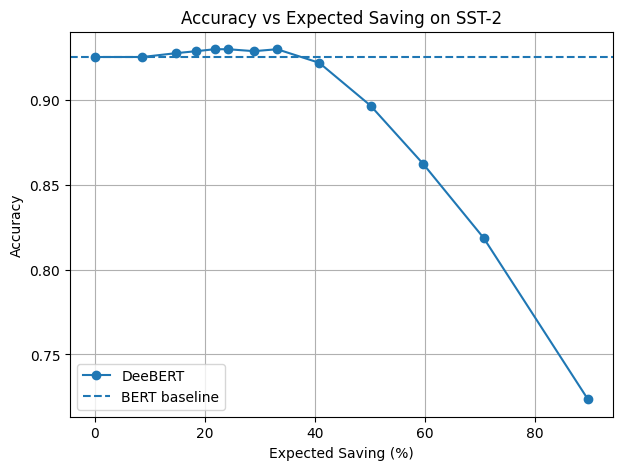

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    result_df["expected_saving_%"],
    result_df["accuracy"],
    marker="o",
    label="DeeBERT"
)

plt.axhline(
    y=baseline_acc,
    linestyle="--",
    label="BERT baseline"
)

plt.xlabel("Expected Saving (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Expected Saving on SST-2")
plt.legend()
plt.grid(True)

plt.savefig("accuracy_vs_expected_saving.png", dpi=300, bbox_inches="tight")
plt.show()

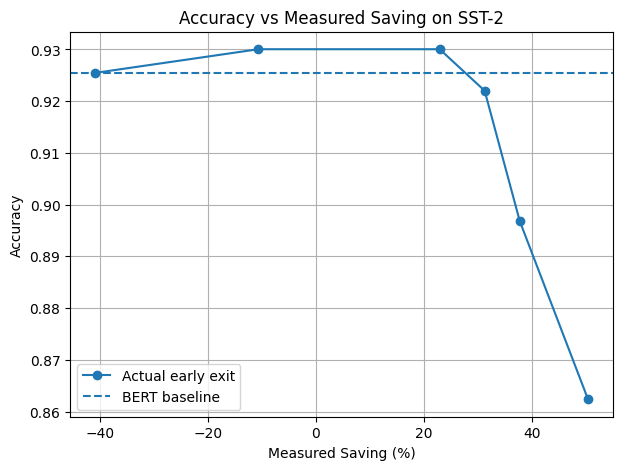

In [67]:
plt.figure(figsize=(7, 5))

plt.plot(
    actual_latency_df["measured_saving_vs_baseline_%"],
    actual_latency_df["accuracy"],
    marker="o",
    label="Actual early exit"
)

plt.axhline(
    y=baseline_latency["accuracy"],
    linestyle="--",
    label="BERT baseline"
)

plt.xlabel("Measured Saving (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Measured Saving on SST-2")
plt.legend()
plt.grid(True)

plt.savefig("accuracy_vs_measured_saving.png", dpi=300, bbox_inches="tight")
plt.show()

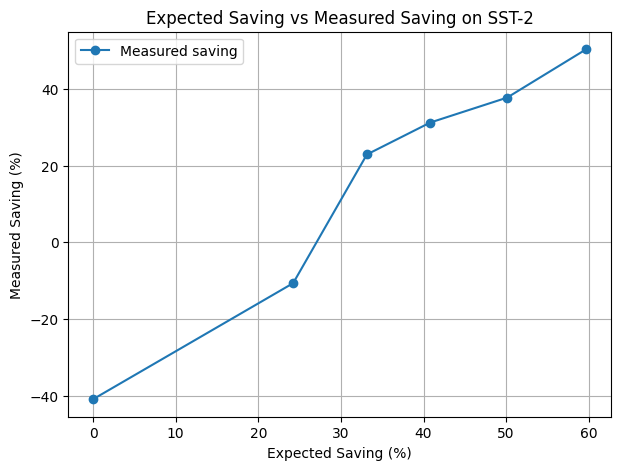

In [68]:
plt.figure(figsize=(7, 5))

plt.plot(
    actual_latency_df["expected_saving_%"],
    actual_latency_df["measured_saving_vs_baseline_%"],
    marker="o",
    label="Measured saving"
)

plt.xlabel("Expected Saving (%)")
plt.ylabel("Measured Saving (%)")
plt.title("Expected Saving vs Measured Saving on SST-2")
plt.legend()
plt.grid(True)

plt.savefig("expected_vs_measured_saving.png", dpi=300, bbox_inches="tight")
plt.show()

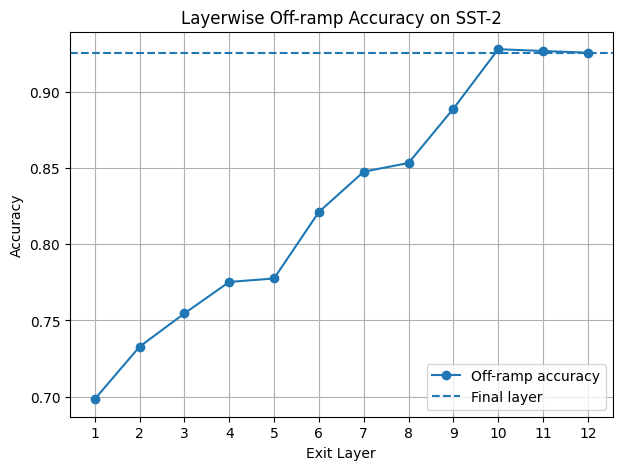

In [69]:
layers = list(range(1, len(layerwise_acc) + 1))

plt.figure(figsize=(7, 5))

plt.plot(
    layers,
    layerwise_acc,
    marker="o",
    label="Off-ramp accuracy"
)

plt.axhline(
    y=layerwise_acc[-1],
    linestyle="--",
    label="Final layer"
)

plt.xlabel("Exit Layer")
plt.ylabel("Accuracy")
plt.title("Layerwise Off-ramp Accuracy on SST-2")
plt.xticks(layers)
plt.legend()
plt.grid(True)

plt.savefig("layerwise_offramp_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [70]:
def plot_actual_exit_distribution(result, filename=None):
    counts = result["exit_layer_counts"]
    total = sum(counts)
    fractions = [count / total for count in counts]
    layers = list(range(1, len(counts) + 1))

    plt.figure(figsize=(7, 4))

    plt.bar(
        layers,
        fractions,
        label=f"S={result['threshold']:.2f}"
    )

    plt.xlabel("Exit Layer")
    plt.ylabel("Fraction of Samples")
    plt.title(f"Exit Layer Distribution on SST-2, S={result['threshold']:.2f}")
    plt.xticks(layers)
    plt.legend()
    plt.grid(axis="y")

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

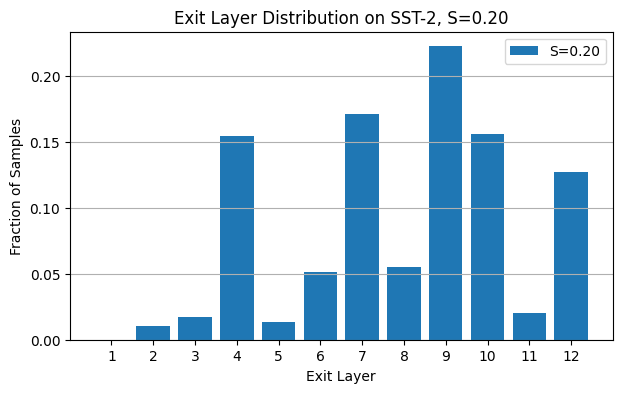

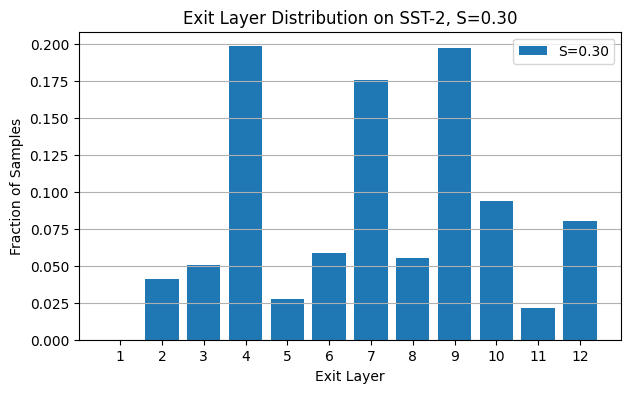

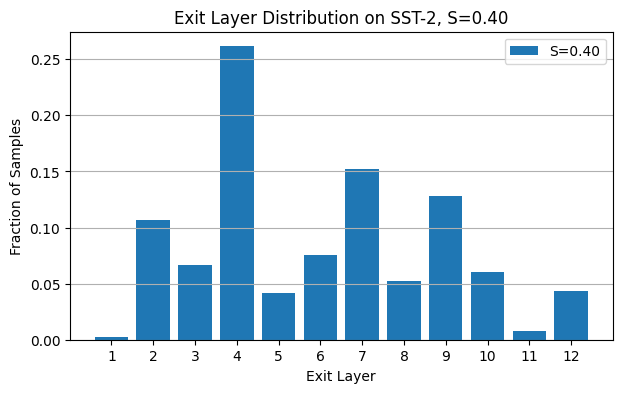

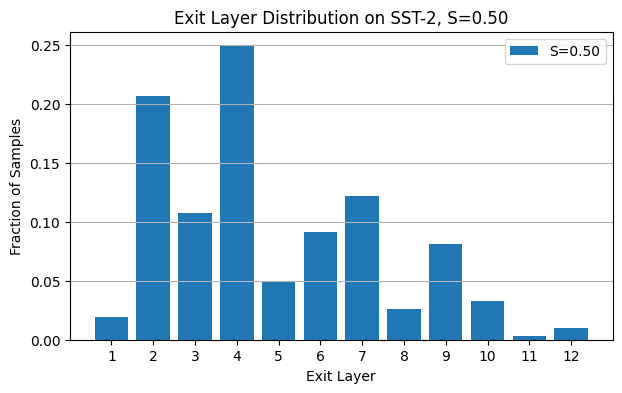

In [71]:
for target_s in [0.20, 0.30, 0.40, 0.50]:
    selected = min(
        actual_latency_results,
        key=lambda r: abs(r["threshold"] - target_s)
    )

    plot_actual_exit_distribution(
        selected,
        filename=f"exit_distribution_S_{target_s:.2f}.png"
    )